In [1]:
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

CLASSIFIED_PATH  = Path("../../data/results/classified_eval_transformer_only.json")
GROUND_TRUTH_PATH = Path("../../data/processed/db_labelled.json")

CLASSES = ["irrelevant", "neutral", "positive", "negative"]
CLASS_COLOURS = {
    "irrelevant": "#B4B2A9",
    "neutral": "#85B7EB",
    "positive": "#97C459",
    "negative": "#F09595",
}

print(f"Classified  : {CLASSIFIED_PATH}")
print(f"Ground truth: {GROUND_TRUTH_PATH}")

Classified  : ..\..\data\results\classified_eval_transformer_only.json
Ground truth: ..\..\data\processed\db_labelled.json


## load data

In [2]:
def load_json(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# Load the raw data
classified_raw = load_json(CLASSIFIED_PATH)
ground_truth_raw_unfiltered = load_json(GROUND_TRUTH_PATH)

# Filter Ground Truth: Keep only IDs that survived the classification pipeline (removes non-English)
classified_ids = {str(post.get("ID", "")) for post in classified_raw}
ground_truth_raw = [
    post for post in ground_truth_raw_unfiltered 
    if str(post.get("ID", "")) in classified_ids
]

removed_count = len(ground_truth_raw_unfiltered) - len(ground_truth_raw)

# Calculate comment counts based on the newly filtered lists
classified_comments   = sum(len(r.get("Comments") or []) for r in classified_raw)
ground_truth_comments = sum(len(r.get("Comments") or []) for r in ground_truth_raw)

print(f"Classified posts: {len(classified_raw):,}")
print(f"Ground truth posts (initial): {len(ground_truth_raw_unfiltered):,}")
print(f"Ground truth posts (aligned): {len(ground_truth_raw):,}  [Removed {removed_count:,} non-English/dropped posts]")

print(f"\nClassified comments: {classified_comments:,}")
print(f"Ground truth comments: {ground_truth_comments:,}")

print(f"\nClassified total records: {len(classified_raw) + classified_comments:,}")
print(f"Ground truth total records: {len(ground_truth_raw) + ground_truth_comments:,}")

Classified posts: 1,200
Ground truth posts (initial): 1,200
Ground truth posts (aligned): 1,200  [Removed 0 non-English/dropped posts]

Classified comments: 966
Ground truth comments: 966

Classified total records: 2,166
Ground truth total records: 2,166


## Label Extraction functions 

In [3]:
def extract_classified_label(record: dict, force_irrelevant: bool = False) -> str:
    if force_irrelevant:
        return "irrelevant"

    subjectivity = str(record.get("Subjectivity", "")).strip().lower()
    if subjectivity == "irrelevant":
        return "irrelevant"

    polarity = str(record.get("Overall_Document_Polarity", "")).strip().lower()
    if polarity in ("neutral", "positive", "negative"):
        return polarity

    # Fallback: try Polarity field from earlier pipeline versions
    polarity_fallback = str(record.get("Polarity", "")).strip().lower()
    if polarity_fallback in ("neutral", "positive", "negative"):
        return polarity_fallback

    return "unknown"


def extract_ground_truth_label(record: dict, force_irrelevant: bool = False) -> str:
    if force_irrelevant:
        return "irrelevant"
    label = str(record.get("label", "")).strip().lower()
    return label if label in CLASSES else "unknown"


print("Label extraction functions defined.")

Label extraction functions defined.


## build aligned record pairs 

In [4]:
# Index ground truth by ID for O(1) lookup
gt_posts_index: dict[str, dict] = {}
gt_comments_index: dict[str, dict] = {}

for post in ground_truth_raw:
    post_id = str(post.get("ID", ""))
    gt_posts_index[post_id] = post
    for comment in post.get("Comments") or []:
        cid = str(comment.get("comment_id", ""))
        gt_comments_index[cid] = comment

# Build aligned lists
y_true: list[str] = []   # ground truth labels
y_pred: list[str] = []   # predicted labels
record_ids: list[str] = []
record_types: list[str] = []   # 'post' or 'comment'
unmatched: list[str] = []

for classified_post in classified_raw:
    post_id = str(classified_post.get("ID", ""))

    # Post-level 
    pred_post_label = extract_classified_label(classified_post)

    if post_id in gt_posts_index:
        true_post_label = extract_ground_truth_label(gt_posts_index[post_id])
        y_pred.append(pred_post_label)
        y_true.append(true_post_label)
        record_ids.append(post_id)
        record_types.append("post")
    else:
        unmatched.append(f"post:{post_id}")

    # if the post is irrelevant, ALL comments are irrelevant
    post_is_irrelevant = (pred_post_label == "irrelevant")

    for comment in classified_post.get("Comments") or []:
        cid = str(comment.get("comment_id", ""))
        pred_comment_label = extract_classified_label(comment, force_irrelevant=post_is_irrelevant)

        if cid in gt_comments_index:
            # Ground truth also applies inheritance: if the GT post is irrelevant,
            # the GT comment is irrelevant regardless of its own label
            gt_post_irrelevant = (
                extract_ground_truth_label(gt_posts_index.get(post_id, {})) == "irrelevant"
                if post_id in gt_posts_index else False
            )
            true_comment_label = extract_ground_truth_label(
                gt_comments_index[cid], force_irrelevant=gt_post_irrelevant
            )
            y_pred.append(pred_comment_label)
            y_true.append(true_comment_label)
            record_ids.append(cid)
            record_types.append("comment")
        else:
            unmatched.append(f"comment:{cid}")

# Build evaluation dataframe
eval_df = pd.DataFrame({
    "ID": record_ids,
    "Type": record_types,
    "y_true": y_true,
    "y_pred": y_pred,
    "correct": [t == p for t, p in zip(y_true, y_pred)],
})

print(f"Matched records : {len(eval_df):,}")
print(f"Posts: {(eval_df['Type'] == 'post').sum():,}")
print(f"Comments: {(eval_df['Type'] == 'comment').sum():,}")
print(f"Unmatched IDs: {len(unmatched)}")
if unmatched:
    print(f"First 10: {unmatched[:10]}")

unknown_true = (eval_df['y_true'] == 'unknown').sum()
unknown_pred = (eval_df['y_pred'] == 'unknown').sum()
if unknown_true or unknown_pred:
    print(f"\n⚠ Unknown labels — true: {unknown_true}  pred: {unknown_pred}")
    print("These records will be excluded from metric calculation.")

Matched records : 2,166
Posts: 1,200
Comments: 966
Unmatched IDs: 0


## Distribution: Ground truth

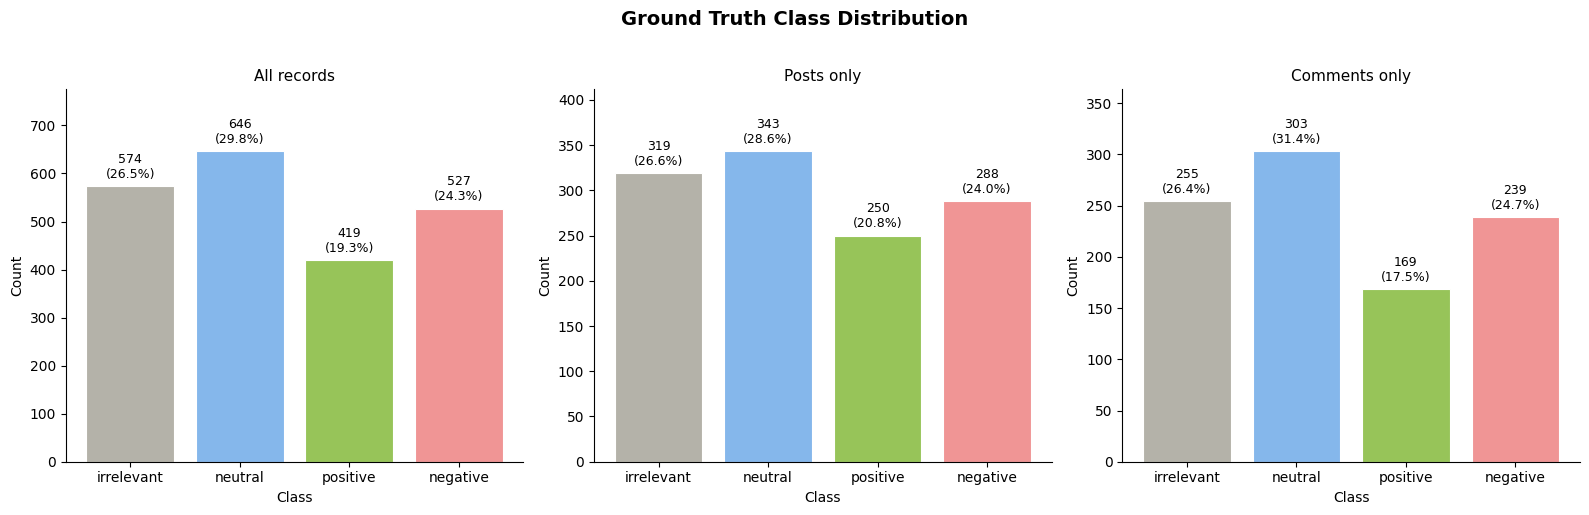


Ground truth distribution (all records):
            Count  Percent
y_true                    
irrelevant    574  26.5000
neutral       646  29.8200
positive      419  19.3400
negative      527  24.3300


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ground Truth Class Distribution", fontsize=14, fontweight="bold", y=1.02)

def plot_distribution(ax, series, title, classes=CLASSES):
    counts = series.value_counts().reindex(classes, fill_value=0)
    total  = counts.sum()
    colours = [CLASS_COLOURS.get(c, "#888") for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colours, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100 if total > 0 else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9
        )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, counts.max() * 1.20)
    ax.spines[["top", "right"]].set_visible(False)
    return counts

gt_all = eval_df[eval_df["y_true"] != "unknown"]["y_true"]
gt_posts = eval_df[(eval_df["y_true"] != "unknown") & (eval_df["Type"] == "post")]["y_true"]
gt_comments= eval_df[(eval_df["y_true"] != "unknown") & (eval_df["Type"] == "comment")]["y_true"]

plot_distribution(axes[0], gt_all, "All records")
plot_distribution(axes[1], gt_posts, "Posts only")
plot_distribution(axes[2], gt_comments, "Comments only")

plt.tight_layout()
plt.savefig("evaluation_diagrams/gt_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGround truth distribution (all records):")
dist_df = gt_all.value_counts().reindex(CLASSES, fill_value=0).rename("Count").to_frame()
dist_df["Percent"] = (dist_df["Count"] / dist_df["Count"].sum() * 100).round(2)
print(dist_df.to_string())

## Class distribution: Classified output

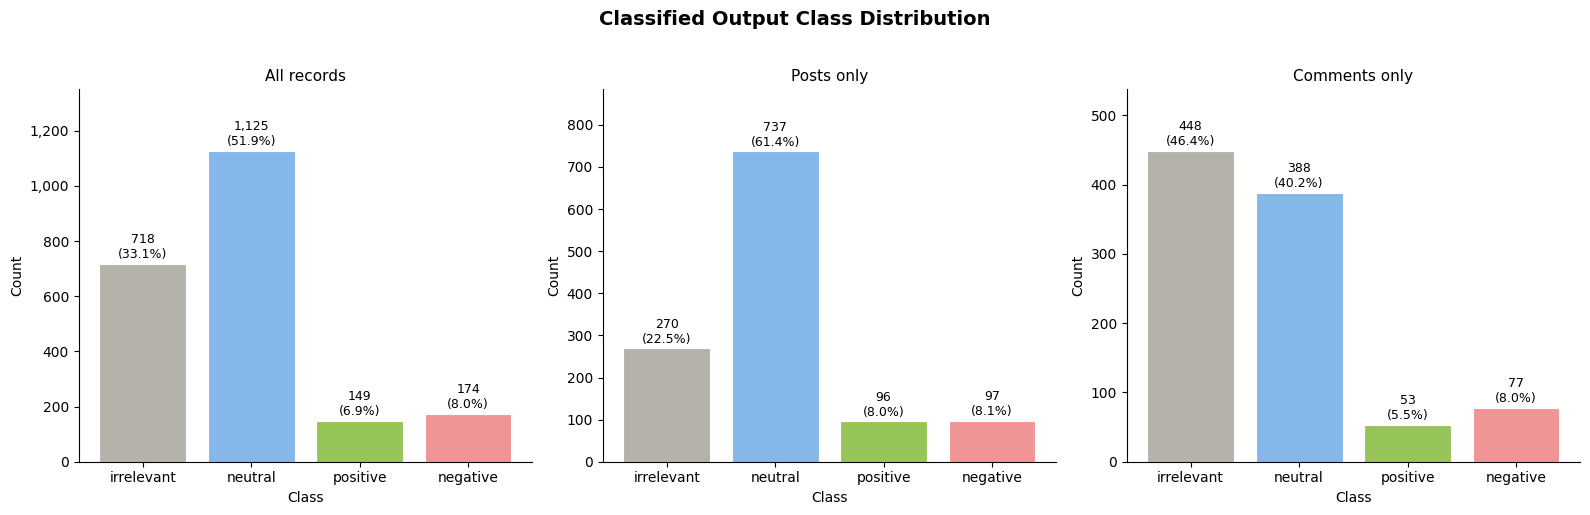


Classified distribution (all records):
            Count  Percent
y_pred                    
irrelevant    718  33.1500
neutral      1125  51.9400
positive      149   6.8800
negative      174   8.0300


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Classified Output Class Distribution", fontsize=14, fontweight="bold", y=1.02)

pred_all = eval_df[eval_df["y_pred"] != "unknown"]["y_pred"]
pred_posts = eval_df[(eval_df["y_pred"] != "unknown") & (eval_df["Type"] == "post")]["y_pred"]
pred_comments = eval_df[(eval_df["y_pred"] != "unknown") & (eval_df["Type"] == "comment")]["y_pred"]

plot_distribution(axes[0], pred_all, "All records")
plot_distribution(axes[1], pred_posts, "Posts only")
plot_distribution(axes[2], pred_comments, "Comments only")

plt.tight_layout()
plt.savefig("evaluation_diagrams/pred_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassified distribution (all records):")
dist_df2 = pred_all.value_counts().reindex(CLASSES, fill_value=0).rename("Count").to_frame()
dist_df2["Percent"] = (dist_df2["Count"] / dist_df2["Count"].sum() * 100).round(2)
print(dist_df2.to_string())

## Confusion matrix

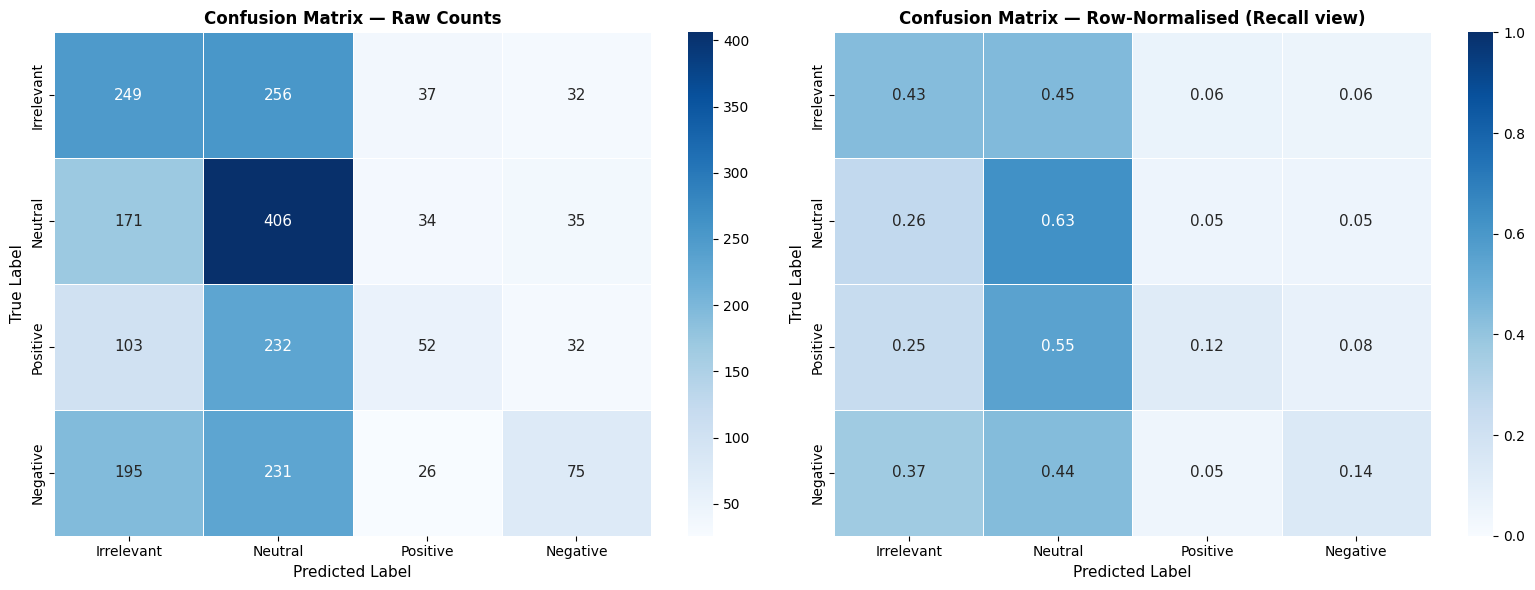

In [7]:
valid = eval_df[(eval_df["y_true"] != "unknown") & (eval_df["y_pred"] != "unknown")]
cm = confusion_matrix(valid["y_true"], valid["y_pred"], labels=CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[c.capitalize() for c in CLASSES],
    yticklabels=[c.capitalize() for c in CLASSES],
    ax=axes[0], linewidths=0.5, linecolor="white",
    annot_kws={"size": 11}
)
axes[0].set_title("Confusion Matrix — Raw Counts", fontsize=12, fontweight="bold")
axes[0].set_ylabel("True Label",      fontsize=11)
axes[0].set_xlabel("Predicted Label", fontsize=11)

# Row-normalised (recall perspective)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_norm, row_sums, where=row_sums != 0)

sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=[c.capitalize() for c in CLASSES],
    yticklabels=[c.capitalize() for c in CLASSES],
    ax=axes[1], linewidths=0.5, linecolor="white",
    vmin=0, vmax=1, annot_kws={"size": 11}
)
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall view)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Label", fontsize=11)
axes[1].set_xlabel("Predicted Label", fontsize=11)

plt.tight_layout()
plt.savefig("evaluation_diagrams/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Per class (Precision, Recall & F1)

In [8]:
valid = eval_df[(eval_df["y_true"] != "unknown") & (eval_df["y_pred"] != "unknown")]

precision, recall, f1, support = precision_recall_fscore_support(
    valid["y_true"], valid["y_pred"],
    labels=CLASSES, zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": [c.capitalize() for c in CLASSES],
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Support": support.astype(int),
}).set_index("Class")

# Macro avg -> calc the metrics for each class individually regardless of how many
# examples of that class exist in dataset
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    valid["y_true"], valid["y_pred"], average="macro",    zero_division=0
)

# weighted avg -> Calc the performance for each class individually, but before avg
# it multiplies each class's scores by its 'support' (actual number of true instances of the class)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    valid["y_true"], valid["y_pred"], average="weighted", zero_division=0
)
accuracy = accuracy_score(valid["y_true"], valid["y_pred"])

# Append summary rows
summary_rows = pd.DataFrame({
    "Class": ["Macro avg", "Weighted avg", "Overall Accuracy"],
    "Precision": [macro_p, weighted_p, accuracy],
    "Recall": [macro_r, weighted_r, accuracy],
    "F1 Score": [macro_f1, weighted_f1, accuracy],
    "Support": [valid.shape[0], valid.shape[0], valid.shape[0]],
}).set_index("Class")

full_metrics = pd.concat([metrics_df, summary_rows])
print("═" * 62)
print("  Per-Class Metrics")
print("═" * 62)
print(full_metrics.to_string(float_format="{:.4f}".format))
print("═" * 62)

══════════════════════════════════════════════════════════════
  Per-Class Metrics
══════════════════════════════════════════════════════════════
                  Precision  Recall  F1 Score  Support
Class                                                 
Irrelevant           0.5191  0.4933    0.5059     2228
Neutral              0.2470  0.5142    0.3337     1056
Positive             0.3753  0.1424    0.2065     1046
Negative             0.2783  0.1245    0.1720      691
Macro avg            0.3550  0.3186    0.3045     5021
Weighted avg         0.3988  0.3738    0.3614     5021
Overall Accuracy     0.3738  0.3738    0.3738     5021
══════════════════════════════════════════════════════════════


## Metrics bar chart


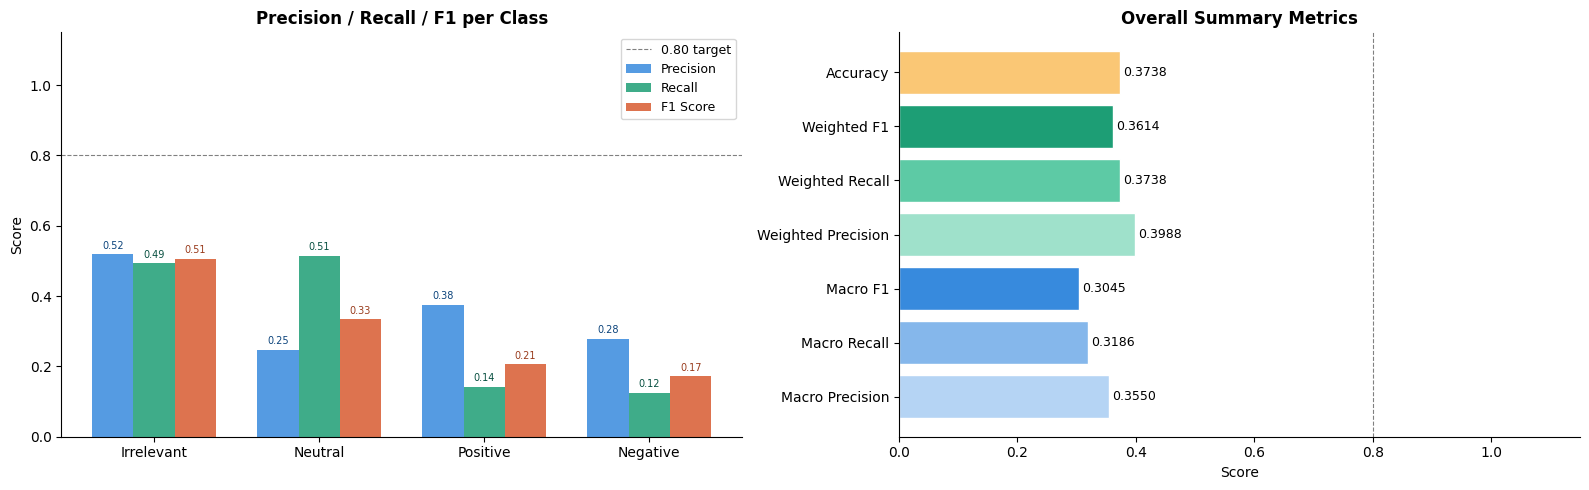

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-class P/R/F1 grouped bar
ax = axes[0]
x      = np.arange(len(CLASSES))
width  = 0.25
ax.bar(x - width, precision, width, label="Precision", color="#378ADD", alpha=0.85)
ax.bar(x, recall, width, label="Recall", color="#1D9E75", alpha=0.85)
ax.bar(x + width, f1, width, label="F1 Score",  color="#D85A30", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CLASSES], fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 per Class", fontsize=12, fontweight="bold")
ax.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, label="0.80 target")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.01, f"{p:.2f}", ha="center", va="bottom", fontsize=7, color="#0C447C")
    ax.text(i, r + 0.01, f"{r:.2f}", ha="center", va="bottom", fontsize=7, color="#085041")
    ax.text(i + width, f + 0.01, f"{f:.2f}", ha="center", va="bottom", fontsize=7, color="#993C1D")

# Summary horizontal bar: macro vs weighted F1
ax2 = axes[1]
metrics_summary = {
    "Macro Precision": macro_p,
    "Macro Recall": macro_r,
    "Macro F1": macro_f1,
    "Weighted Precision" : weighted_p,
    "Weighted Recall": weighted_r,
    "Weighted F1": weighted_f1,
    "Accuracy": accuracy,
}
colours_summary = [
    "#B5D4F4","#85B7EB","#378ADD",
    "#9FE1CB","#5DCAA5","#1D9E75",
    "#FAC775"
]
bars = ax2.barh(
    list(metrics_summary.keys()),
    list(metrics_summary.values()),
    color=colours_summary, edgecolor="white"
)
for bar, val in zip(bars, metrics_summary.values()):
    ax2.text(
        val + 0.005, bar.get_y() + bar.get_height()/2,
        f"{val:.4f}", va="center", fontsize=9
    )
ax2.set_xlim(0, 1.15)
ax2.axvline(0.8, color="gray", linestyle="--", linewidth=0.8)
ax2.set_title("Overall Summary Metrics", fontsize=12, fontweight="bold")
ax2.set_xlabel("Score")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("evaluation_diagrams/metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Separate metrics: Posts vs Comments

In [10]:
def compute_metrics(subset: pd.DataFrame, label: str):
    sub = subset[(subset["y_true"] != "unknown") & (subset["y_pred"] != "unknown")]
    if len(sub) == 0:
        print(f"No valid records in subset: {label}")
        return None

    p, r, f, s = precision_recall_fscore_support(
        sub["y_true"], sub["y_pred"], labels=CLASSES, zero_division=0
    )
    acc = accuracy_score(sub["y_true"], sub["y_pred"])
    macro_f1 = f.mean()
    _, _, wf1, _ = precision_recall_fscore_support(
        sub["y_true"], sub["y_pred"], average="weighted", zero_division=0
    )

    df = pd.DataFrame({
        "Class": [c.capitalize() for c in CLASSES],
        "Precision": p,
        "Recall": r,
        "F1": f,
        "Support": s.astype(int),
    }).set_index("Class")

    print(f"\n{'━'*55}")
    print(f"  {label}   (N={len(sub):,})")
    print(f"{'━'*55}")
    print(df.to_string(float_format="{:.4f}".format))
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {wf1:.4f}")
    print(f"Accuracy: {acc:.4f}")
    return df

posts_df    = compute_metrics(eval_df[eval_df["Type"] == "post"],    "POSTS")
comments_df = compute_metrics(eval_df[eval_df["Type"] == "comment"], "COMMENTS")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  POSTS   (N=2,000)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            Precision  Recall     F1  Support
Class                                        
Irrelevant     0.4951  0.5427 0.5178      750
Neutral        0.2417  0.4636 0.3178      440
Positive       0.3591  0.1305 0.1915      498
Negative       0.3203  0.1571 0.2108      312
Macro F1: 0.3094
Weighted F1: 0.3446
Accuracy: 0.3625

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  COMMENTS   (N=3,021)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            Precision  Recall     F1  Support
Class                                        
Irrelevant     0.5344  0.4682 0.4991     1478
Neutral        0.2504  0.5503 0.3442      616
Positive       0.3889  0.1533 0.2199      548
Negative       0.2372  0.0976 0.1383      379
Macro F1: 0.3004
Weighted F1: 0.3716
Accuracy: 0.3813


## Full classification report

In [11]:
valid = eval_df[(eval_df["y_true"] != "unknown") & (eval_df["y_pred"] != "unknown")]

report = classification_report(
    valid["y_true"], valid["y_pred"],
    labels=CLASSES,
    target_names=[c.capitalize() for c in CLASSES],
    digits=4,
    zero_division=0,
)
print("Full Classification Report (All Records)")
print("=" * 62)
print(report)

Full Classification Report (All Records)
              precision    recall  f1-score   support

  Irrelevant     0.5191    0.4933    0.5059      2228
     Neutral     0.2470    0.5142    0.3337      1056
    Positive     0.3753    0.1424    0.2065      1046
    Negative     0.2783    0.1245    0.1720       691

    accuracy                         0.3738      5021
   macro avg     0.3550    0.3186    0.3045      5021
weighted avg     0.3988    0.3738    0.3614      5021



## Error analysis (Misclassified records)

Total misclassified : 3,144 / 5,021  (62.62%)
Posts misclassified : 1,275
Comments misclass.  : 1,869

Top confusion pairs (true → predicted):
error_type
irrelevant → neutral     917
positive → neutral       467
positive → irrelevant    361
neutral → irrelevant     359
negative → irrelevant    298
negative → neutral       271
irrelevant → positive    121
neutral → positive        91
irrelevant → negative     91
positive → negative       69
neutral → negative        63
negative → positive       36


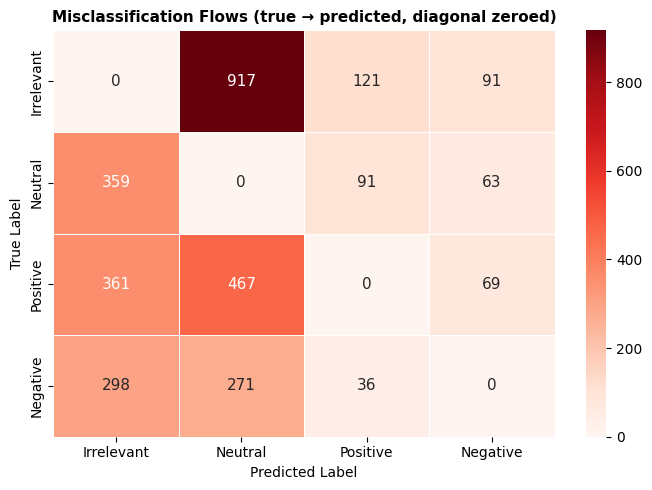

In [12]:
errors = eval_df[
    (eval_df["correct"] == False) &
    (eval_df["y_true"] != "unknown") &
    (eval_df["y_pred"] != "unknown")
].copy()

errors["error_type"] = errors["y_true"] + " → " + errors["y_pred"]

print(f"Total misclassified : {len(errors):,} / {len(eval_df):,}  "
      f"({len(errors)/len(eval_df)*100:.2f}%)")
print(f"Posts misclassified : {(errors['Type']=='post').sum():,}")
print(f"Comments misclass.  : {(errors['Type']=='comment').sum():,}")

print("\nTop confusion pairs (true → predicted):")
pair_counts = errors["error_type"].value_counts().head(15)
print(pair_counts.to_string())

# Heatmap of error flows
error_pivot = errors.groupby(["y_true", "y_pred"]).size().unstack(fill_value=0)
# Reindex to ensure all classes appear
error_pivot = error_pivot.reindex(index=CLASSES, columns=CLASSES, fill_value=0).copy()

for c in CLASSES:
    error_pivot.loc[c, c] = 0

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    error_pivot, annot=True, fmt="d", cmap="Reds",
    xticklabels=[c.capitalize() for c in CLASSES],
    yticklabels=[c.capitalize() for c in CLASSES],
    ax=ax, linewidths=0.5, linecolor="white",
    annot_kws={"size": 11}
)
ax.set_title("Misclassification Flows (true → predicted, diagonal zeroed)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("True Label",fontsize=10)
ax.set_xlabel("Predicted Label", fontsize=10)
plt.tight_layout()
plt.savefig("evaluation_diagrams/error_flows.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary table

In [13]:
valid = eval_df[(eval_df["y_true"] != "unknown") & (eval_df["y_pred"] != "unknown")]

p_arr, r_arr, f_arr, s_arr = precision_recall_fscore_support(
    valid["y_true"], valid["y_pred"], labels=CLASSES, zero_division=0
)
_, _, macro_f1_val,    _ = precision_recall_fscore_support(valid["y_true"], valid["y_pred"], average="macro",    zero_division=0)
_, _, weighted_f1_val, _ = precision_recall_fscore_support(valid["y_true"], valid["y_pred"], average="weighted", zero_division=0)
acc_val = accuracy_score(valid["y_true"], valid["y_pred"])

summary = pd.DataFrame({
    "Class": [c.capitalize() for c in CLASSES] + ["Macro Avg", "Weighted Avg", "Accuracy"],
    "Precision": list(p_arr) + ["", "", ""],
    "Recall": list(r_arr) + ["", "", ""],
    "F1 Score": list(f_arr) + [macro_f1_val, weighted_f1_val, acc_val],
    "Support (GT)": list(s_arr.astype(int)) + ["", "", valid.shape[0]],
})

# Format floats
for col in ["Precision", "Recall", "F1 Score"]:
    summary[col] = summary[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print("╔══════════════════════════════════════════════════════════════╗")
print("║         SC4021 Evaluation Summary — All Records              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(summary.to_string(index=False))
print("╚══════════════════════════════════════════════════════════════╝")
print(f"\nTotal evaluated records : {valid.shape[0]:,}")
print(f"Overall accuracy: {acc_val:.4f}  ({acc_val*100:.2f}%)")
print(f"Macro F1: {macro_f1_val:.4f}")
print(f"Weighted F1: {weighted_f1_val:.4f}")

╔══════════════════════════════════════════════════════════════╗
║         SC4021 Evaluation Summary — All Records              ║
╠══════════════════════════════════════════════════════════════╣
       Class Precision Recall F1 Score Support (GT)
  Irrelevant    0.5191 0.4933   0.5059         2228
     Neutral    0.2470 0.5142   0.3337         1056
    Positive    0.3753 0.1424   0.2065         1046
    Negative    0.2783 0.1245   0.1720          691
   Macro Avg                    0.3045             
Weighted Avg                    0.3614             
    Accuracy                    0.3738         5021
╚══════════════════════════════════════════════════════════════╝

Total evaluated records : 5,021
Overall accuracy: 0.3738  (37.38%)
Macro F1: 0.3045
Weighted F1: 0.3614
